In [54]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

In [41]:
# NSL-KDD columns
with open("feature_names.txt") as f:
    cols = [line.strip() for line in f]

# Load data
train = pd.read_csv("KDDTrain+.txt", names=cols)
test = pd.read_csv("KDDTest+.txt", names=cols)

# Verify dataset dimensions
assert train.shape[1] == 43
assert test.shape[1] == 43

print("Training set shape:", train.shape)
print("Test set shape:", test.shape)


Training set shape: (125973, 43)
Test set shape: (22544, 43)


In [44]:
#To be included in github repo

#Data preprocessing included:

#- Binary conversion of class labels
#- Label encoding of categorical features
#- Verification that all features were numeric before training


In [45]:
# Convert attack labels to binary classification:
# normal traffic -> 0
# attack traffic -> 1
train['label'] = train['label'].apply(
    lambda x: 0 if str(x).strip().startswith("normal") else 1
)

test['label'] = test['label'].apply(
    lambda x: 0 if str(x).strip().startswith("normal") else 1
)


# Label-encode categorical features
# using combined train+test values
# to ensure consistent category mappings
for col in ['protocol_type','service','flag']:

    le = LabelEncoder()

    allvals = pd.concat([train[col], test[col]])

    le.fit(allvals)

    train[col] = le.transform(train[col])
    test[col] = le.transform(test[col])

In [49]:
# Split features (X) and target labels (y)
X_train = train.drop('label', axis=1)
y_train = train['label']

X_test = test.drop('label', axis=1)
y_test = test['label']


# Replace any missing values with 0
# to ensure clean numeric input for model training
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

In [53]:
# Initialize Random Forest classifier
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model on the training dataset
model.fit(X_train, y_train)

# Generate predictions on unseen test data
pred = model.predict(X_test)

              precision    recall  f1-score   support

           0       0.72      0.97      0.83      9711
           1       0.97      0.71      0.82     12833

    accuracy                           0.82     22544
   macro avg       0.84      0.84      0.82     22544
weighted avg       0.86      0.82      0.82     22544

Test Accuracy: 0.8238112136266856
Confusion Matrix:
[[9443  268]
 [3704 9129]]


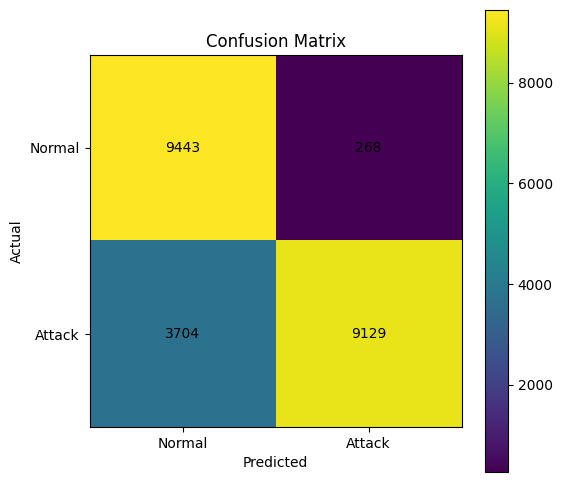

In [56]:
# Evaluate model performance:
# precision, recall, F1-score, and overall accuracy
print(classification_report(y_test, pred))
print("Test Accuracy:", model.score(X_test, y_test))

# Compute and print confusion matrix
cm = confusion_matrix(y_test, pred)
print("Confusion Matrix:")
print(cm)

# Visualize confusion matrix
plt.figure(figsize=(6,6))
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks([0,1], ['Normal','Attack'])
plt.yticks([0,1], ['Normal','Attack'])
plt.xlabel("Predicted")
plt.ylabel("Actual")

# Annotate confusion matrix cells
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i,j], ha='center', va='center')

plt.show()